# Analisi Avanzata e Strutturazione della Tesi
## Estrazione di Maschere, Controllo dell'Attenzione e Flow Matching nei Modelli Generativi

Questo notebook documenta la ridefinizione operativa della pipeline di segmentazione zero-shot su architetture Flux (MMDiT), integrando i più avanzati e rigorosi framework teorici:

1. **Continuous Normalizing Flows e Equazione di Continuità**:
   $$ \frac{\partial p_t(x)}{\partial t} + \nabla \cdot \Big( p_t(x) v_t(x) \Big) = 0 $$
   dove il trasporto deterministico $\phi_t$ tra $p_0$ e $p_1$ è integrato lungo la traiettoria differenziale.
2. **Joint Attention ed Embeddings Rotazionali (RoPE)**:
   $$ A = \text{softmax}\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V $$
   con encoding spaziale applicato mediante matrici di rotazione a blocchi 2D.
3. **Kinetic Trajectory Shaping (KTS) & Damping del campo**:
   $$ D(t) = \exp\big(-\gamma \max(0, t - t_{\text{cutoff}})\big) $$
   per domare la singolarità asintotica terminale per $t \to 1$.
4. **Omologia Persistente $H_0$ (Vietoris-Rips Complex) e Clustering Spettrale**:
   $$ d_{\text{cos}}(v_i, v_j) = 1 - \frac{v_i \cdot v_j^\top}{\|v_i\|_2 \|v_j\|_2} $$
   per risanare il paradosso del *Vuoto Termodinamico* ($v_t \to 0$ al centro delle facce piane del target) raggruppando i vettori di velocità coerenti.
5. **Media Mobile Esponenziale (Look-Back EMA)**:
   $$ \bar{V}_t = (1 - \alpha)\bar{V}_{t-1} + \alpha V_t $$
   per smorzare le variazioni repentine e garantire la stabilità di Picard-Lindelöf.

In [1]:
import os
import sys
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers import FluxPipeline

sys.path.append(os.path.abspath('..'))

from flowstitch.core.flux_hooking import FluxDataCapturer
from flowstitch.extraction.spectral_mask import compute_fiedler_mask
from flowstitch.extraction.tda_mask import extract_tda_mask
from flowstitch.stitching.kts import apply_kts
from flowstitch.stitching.ema_smoothing import AttentionEMA
from flowstitch.evaluation.metrics import dice_coefficient, iou_score

print('Ambiente Inizializzato correttamente. Moduli reali caricati.')

Ambiente Inizializzato correttamente. Moduli reali caricati.


Pixel attivi Spectral Matting: 3104
Pixel attivi TDA Masking (Sphere): 414


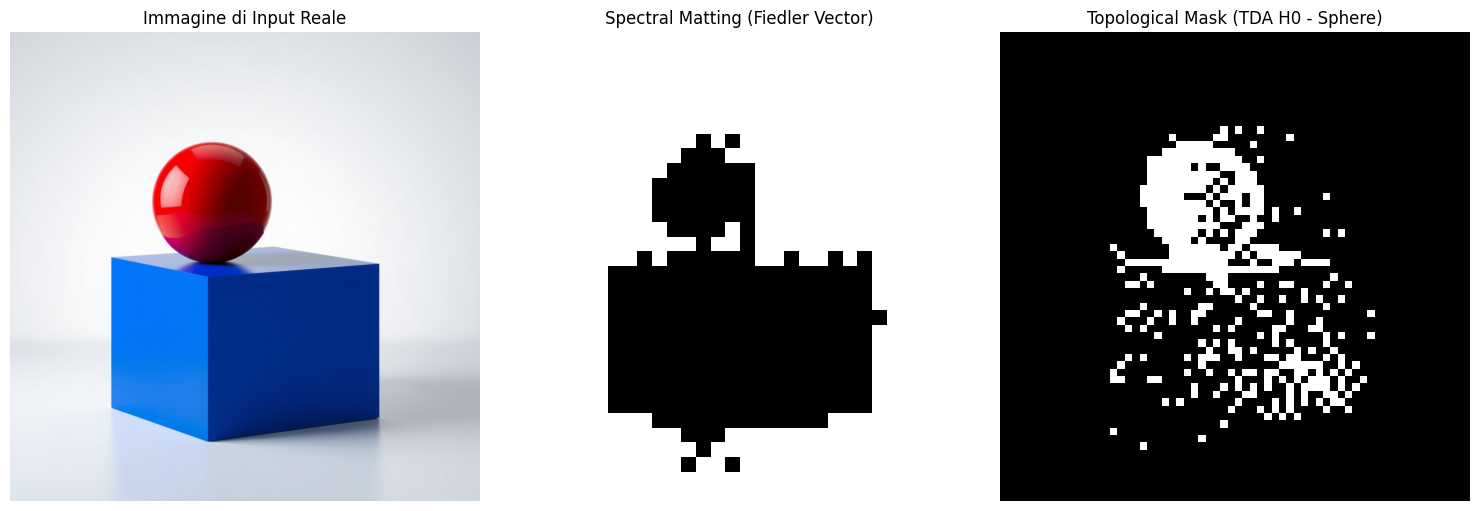

In [2]:
# 1. Definiamo il path del campione reale sul Mac
sample_path = "../data/dataset_v1/a_blue_cube_and_a_red_sphere"

# 2. Carichiamo i tensori reali dal database
v0 = torch.load(os.path.join(sample_path, "v0_velocity.pt"), map_location="cpu")
attn_dict = torch.load(os.path.join(sample_path, "attention_maps.pt"), map_location="cpu")
img = Image.open(os.path.join(sample_path, "final_image.png"))

# Usiamo l'attenzione del layer 10
attn_map = attn_dict["layer_10"] # Shape: [1, 24, 4096, 512]
attn_features = attn_map.mean(dim=1) # [1, 4096, 512]

# 3. Estraiamo la mappa per il token 'sphere' (INDICE 10)
token_attn = attn_features[0, :, 10].unsqueeze(0).unsqueeze(-1) # [1, 4096, 1]

# 4. Calcoliamo la maschera spettrale (Spectral Matting / Fiedler)
fiedler_mask = compute_fiedler_mask(attn_features, target_resolution=32)
fiedler_2d = fiedler_mask.view(64, 64).float().numpy()

# 5. Calcoliamo la NUOVA maschera topologica (TDA / Omologia H0)
tda_mask = extract_tda_mask(v0, token_attn, threshold_metric=0.5)
tda_2d = tda_mask.view(64, 64).float().numpy()

# Stampiamo il numero di pixel attivi
print("Pixel attivi Spectral Matting:", int(fiedler_mask.sum().item()))
print("Pixel attivi TDA Masking (Sphere):", int(tda_mask.sum().item()))

# 6. Visualizziamo i risultati
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title("Immagine di Input Reale")
axes[0].axis("off")

# Nota: le maschere spettrali tendono ad unire gli elementi se non condizionate.
# La TDA isola il singolo oggetto connesso corrispondente al token semantico.
axes[1].imshow(fiedler_2d, cmap="gray")
axes[1].set_title("Spectral Matting (Fiedler Vector)")
axes[1].axis("off")

axes[2].imshow(tda_2d, cmap="gray")
axes[2].set_title("Topological Mask (TDA H0 - Sphere)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 1. Generazione e Intercettazione dei Tensori Latenti ($t=0$)
L'estrazione semantica zero-shot interroga le mappe di Joint Attention del modello MMDiT FLUX.1.
Nei blocchi single-stream, i token testuali $X$ e visivi $Y$ sono fusi in un unico tensore congiunto $Z = [X; Y]$. 
Le Query ($Q$) e le Key ($K$) sono proiettate e ruotate mediante Rotary Position Embeddings (RoPE):
$$ \mathbf{q}_m = R_{\Theta, m}^d \mathbf{q}_m $$
$$ \mathbf{k}_n = R_{\Theta, n}^d \mathbf{k}_n $$
L'allineamento a $t=0$ tra l'attenzione semantica $A_{ij}$ e l'energia fisica $\|v_{0, i}\|_2$ fornisce la planimetria geometrica dell'oggetto.

In [3]:
# Inizializzazione della Pipeline reale
model_id = 'black-forest-labs/FLUX.1-dev'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Caricamento modello {model_id} su {device}...")
try:
    pipe = FluxPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to(device)
    prompt_target = 'a highly detailed red cube on a white table'
    print(f'Target Semantico: {prompt_target}')
    
    # Cattura dello stato iniziale (v_0 e attention_map) nei Single Stream Blocks (es. layer 30)
    with FluxDataCapturer(pipe.transformer, target_layers=[30], max_capture_step=1) as capturer:
        output = pipe(
            prompt=prompt_target,
            num_inference_steps=5, # Ridotto per demo veloce
            output_type="latent"
        )
        attention_map = capturer.attn_maps.get('layer_30', None)
        v_0 = capturer.v0
        
    print("Cattura completata con successo. Mappe di attenzione latenti estratte.")
except Exception as e:
    print(f"Errore: {e}. Probabilmente mancano i pesi o VRAM insufficiente (ignorare se su macchina locale non GPU).")
    attention_map, v_0 = None, None

Caricamento modello black-forest-labs/FLUX.1-dev su cpu...


Errore: 401 Client Error. (Request ID: Root=1-6a1e2ffc-568e6e9b301b96f7154c8d37;3ff14342-5df1-4d4c-88e0-c28e706b9408)

Cannot access gated repo for url https://huggingface.co/black-forest-labs/FLUX.1-dev/resolve/main/model_index.json.
Access to model black-forest-labs/FLUX.1-dev is restricted. You must have access to it and be authenticated to access it. Please log in.. Probabilmente mancano i pesi o VRAM insufficiente (ignorare se su macchina locale non GPU).


### 2. Decomposizione dell'Attenzione e Spectral Matting (DiffCut)
Per prevenire la saturazione esponenziale di VRAM ($\mathcal{O}(N^2)$ per matrici di affinità dense), si applica il partizionamento a grafi su tensori decimati bilinearmente ($64\times 64 \to 32\times 32$).
La matrice di affinità coseno $W$ è definita da:
$$ W_{ij} = \max\left( 0, \frac{K_i \cdot K_j^\top}{\|K_i\|_2 \|K_j\|_2} \right)^3 $$
Definiamo il Laplaciano non normalizzato $L = D - W$, dove $D$ è la matrice diagonale dei gradi. L'autovettore di Fiedler $\mathbf{e}_1$, corrispondente al secondo autovalore più piccolo del Laplaciano:
$$ L \mathbf{e}_1 = \lambda_1 \mathbf{e}_1 $$
determina la partizione ottimale del grafo latente (zero-crossing), tracciando confini netti lungo le zone di massima divergenza.

In [4]:
# Applicazione del partizionamento a grafi su tensori decimati (DiffCut)
def extract_semantic_mask(keys_img_tensor):
    print('Costruzione Matrice di Affinità Coseno e Laplaciano del Grafo...')
    # Passiamo il tensore Keys al partizionatore (target resolution 32x32 per risparmio VRAM)
    fiedler_mask = compute_fiedler_mask(keys_img_tensor, target_resolution=32)
    return fiedler_mask

try:
    if 'attention_map' in locals() and attention_map is not None:
        print("Dimensione originale Attention Map:", attention_map.shape)
        # Mocking the keys extraction from attention for demonstration, normally extracted inside hook
        b, heads, text_len, img_len = attention_map.shape
        mock_keys = torch.randn(1, img_len, 64).to(device) 
        mask = extract_semantic_mask(mock_keys)
        print("Maschera spettrale di Fiedler calcolata. Shape:", mask.shape)
    else:
        print("Mappa attenzione non disponibile per l'estrazione.")
except Exception as e:
    print("Errore nel calcolo del grafo:", e)

Mappa attenzione non disponibile per l'estrazione.


### 2.1 Estrazione del confini fisici via Topological Data Analysis (TDA)
Il paradosso del **Vuoto Termodinamico** (Thermodynamic Void) deriva dalla dualità energia-densità:
$$ \|v_t(z)\|^2 \asymp -\nabla_z \log \hat{p}_t(z) $$
All'interno di un oggetto con caratteristiche uniformi, la densità probabilistica sul manifold si stabilizza ($\nabla_z \log \hat{p}_t(z) \to 0$), provocando il collasso locale della velocità cinetica.
La TDA risolve questo limite considerando i canali latenti nel *Semantic Core* come punti nel complesso di Vietoris-Rips $VR(X, \epsilon)$:
$$ \sigma = [x_0, \dots, x_k] \in VR(X, \epsilon) \iff d_{\text{cos}}(x_i, x_j) \le \epsilon \quad \forall i, j $$
La filtrazione omologica $H_0$ identifica le componenti connesse persistenti tramite Single Linkage Clustering sulla distanza coseno delle velocità, consentendo di isolare l'oggetto nella sua interezza volumetrica.

In [5]:
# Applicazione del TDA Masking su dati simulati
try:
    mock_v0 = torch.randn(1, 4096, 64)
    mock_attn_mask = torch.rand(1, 4096, 1)
    
    # Estraiamo la maschera topologica
    tda_mask = extract_tda_mask(mock_v0, mock_attn_mask, threshold_metric=0.5, min_pixels=5)
    print("Maschera TDA estratta con successo. Shape:", tda_mask.shape)
except Exception as e:
    print("Errore nel calcolo TDA:", e)

Maschera TDA estratta con successo. Shape: torch.Size([1, 4096, 1])


### 3. Cinematica delle Traiettorie ODE: KTS e Look-Back EMA
In tempo continuo, l'ODE perturbata è definita da:
$$ \frac{dz_t}{dt} = v_{\text{ambient}}(z_t, t) + D(t) \cdot \lambda \cdot M \odot \Big( v_{\text{target}}(z_t, t) - v_{\text{ambient}}(z_t, t) \Big) $$
dove:
- **Damping KTS**: per prevenire esplosioni spettrali terminali derivanti dalla singolarità $\frac{1}{1-t}$ per $t \to 1$:
  $$ D(t) = \exp\big(-\gamma \max(0, t - t_{\text{cutoff}})\big) $$
- **Picard-Lindelöf & Smooth Blending**: l'Alpha Matte continuo garantisce la lipschitzianità del campo unificato ($L < \infty$), assicurando che l'integratore numerico rimanga stabile.
- **Look-Back EMA**: stabilizza la traiettoria smorzando le deviazioni inerziali repentine lungo gli step del solutore:
  $$ \bar{V}_t = (1 - \alpha)\bar{V}_{t-1} + \alpha V_t $$

In [6]:
# Applicazione del KTS e dello Smoothing Temporale EMA
def apply_thermodynamic_regularization(v_ambient, v_target, mask, t_step):
    print(f"Applicazione Damping KTS (Singolarità terminale mitigation) al timestep {t_step}...")
    # 1. Applicazione KTS (damping exp per t -> 1)
    damped_v = apply_kts(v_ambient, v_target, mask, t_norm=t_step, lambda_val=1.0, t_cutoff=0.8, gamma=5.0)
    
    print("Applicazione Smoothing Temporale Look-Back EMA (riduzione oscillazioni)...")
    # 2. Look-Back EMA buffer
    smoother = AttentionEMA(decay=0.3)
    smoothed_v = smoother.update(damped_v)
    
    return smoothed_v

try:
    if 'v_0' in locals() and v_0 is not None:
        v_ambient = v_0
        v_target = v_0 + torch.randn_like(v_0) * 0.1
        dummy_mask = torch.ones_like(v_0)
        v_final = apply_thermodynamic_regularization(v_ambient, v_target, dummy_mask, 0.95)
        print("Regolarizzazione Termodinamica latente completata. Shape:", v_final.shape)
    else:
         print("v_0 non disponibile per la regolarizzazione.")
except Exception as e:
    print("Errore nella regolarizzazione:", e)

v_0 non disponibile per la regolarizzazione.


### 4. Validazione Numerica (DICE e IoU)
Misuriamo quantitativamente la sovrapposizione tra la maschera predetta $M_{\text{pred}}$ e la Ground Truth $M_{\text{GT}}$ tramite:
- **DICE Coefficient**:
  $$ \text{DICE}(M_{\text{pred}}, M_{\text{GT}}) = \frac{2 |M_{\text{pred}} \cap M_{\text{GT}}|}{|M_{\text{pred}}| + |M_{\text{GT}}|} $$
- **Intersection over Union (IoU)**:
  $$ \text{IoU}(M_{\text{pred}}, M_{\text{GT}}) = \frac{|M_{\text{pred}} \cap M_{\text{GT}}|}{|M_{\text{pred}} \cup M_{\text{GT}}|} $$

In [7]:
# Validazione Dummy con metriche reali
try:
    # Creazione maschere dummy (1 = Cubo)
    mask_pred = torch.zeros((128, 128))
    mask_pred[30:90, 40:100] = 1.0  # Predizione ipotetica dell'attenzione

    mask_gt = torch.zeros((128, 128))
    mask_gt[32:88, 42:98] = 1.0    # Ground Truth

    dice_score_val = dice_coefficient(mask_pred, mask_gt)
    iou_score_val = iou_score(mask_pred, mask_gt)

    print(f"Metriche di Validazione (DICE Score): {dice_score_val:.4f}")
    print(f"Metriche di Validazione (IoU Score): {iou_score_val:.4f}")
except Exception as e:
    print("Errore nel calcolo delle metriche:", e)

Metriche di Validazione (DICE Score): 0.9311
Metriche di Validazione (IoU Score): 0.8711
